求解矩阵形式的OS方程

In [39]:
module chebyshev_method

    using LinearAlgebra

    export chebyshev_D
    # Chebyshev compute D = differentiation matrix, x = Chebyshev grid

    function  chebyshev_D(N)

        if N==0
            D = 0;
            x = 1;
            return D, x
        else
            θ = range(0, pi, N+1)
            x = reshape(-cos.(θ), N+1, 1)
            c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
            X = repeat(x, 1, N+1);
            dX = X - X';
            D = (c * (1 ./ c)') ./ (dX .+ I(N+1));   # off-diagonal entries
            D = D - diagm(vec(sum(D, dims=2)));      # diagonal entries
            return D, x
        end
    end
end

import .chebyshev_method as cheby
using LinearAlgebra
using BlockDiagonals
using SparseArrays

function generate_matrix(U0, W0, dU0, dW0, c2)

   #定义矩阵
   A = zeros(4, 4)
   B = zeros(4, 4)
   C = zeros(4, 4)
   D = zeros(4, 4)
   Γ = zeros(4, 4)

   V_xx = zeros(4, 4)
   V_yy = zeros(4, 4)
   V_zz = zeros(4, 4)

   Γ[1, 1] = 1.0e0
   Γ[2, 2] = 1.0e0
   Γ[3, 3] = 1.0e0
   Γ[4, 4] = 1.0e0
   A[1, 1] = U0
   A[2, 2] = U0
   A[3, 3] = U0
   A[1, 4] = 1.0e0
   A[4, 1] = c2

   B[2, 4] = 1.0e0
   B[4, 2] = c2
   
   C[1, 1] = W0
   C[2, 2] = W0
   C[3, 3] = W0
   C[3, 4] = 1.0e0
   C[4, 3] = c2

   D[1, 2] = dU0
   D[3, 2] = dW0

   V_xx[1, 1] = 1.0e0
   V_xx[2, 2] = 1.0e0
   V_xx[3, 3] = 1.0e0

   V_yy = -V_xx
   V_zz = V_xx

   return sparse(Γ), sparse(A), sparse(B), sparse(C), sparse(D), sparse(V_xx), sparse(V_yy), sparse(V_zz)

end



generate_matrix (generic function with 1 method)

In [40]:
function channel_flow(y)

   U = 1.0e0 .- y.^2
   W = zeros(size(y))
   dU = -2.0e0 .* y
   dW = zeros(size(y))
   return U, W, dU, dW
end 

channel_flow (generic function with 1 method)

In [41]:
c2 = 10.0^2
n = 100
(alpha, beta) = (1.02e0, 0.0e0)
Re = 5772.2

D_y, y = cheby.chebyshev_D(n);
U0, W0, dU0, dW0 = channel_flow(y)


([0.0; 0.0009866357858641095; … ; 0.0009866357858641095; 0.0;;], [0.0; 0.0; … ; 0.0; 0.0;;], [2.0; 1.9990131207314632; … ; -1.9990131207314632; -2.0;;], [0.0; 0.0; … ; 0.0; 0.0;;])

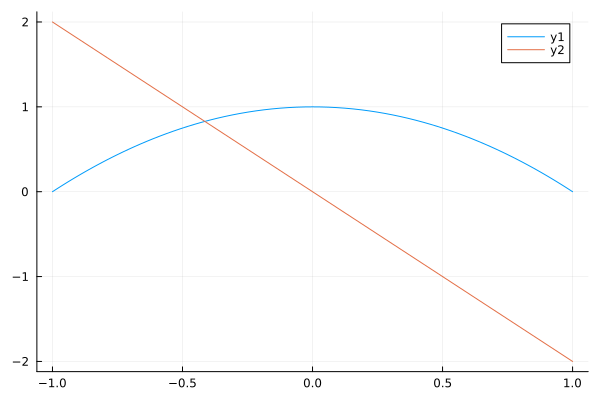

In [42]:
using Plots
plot(y, U0)
plot!(y, dU0)

In [79]:
Γ = Array{typeof(rand(4, 4))}(undef, n+1)
A = copy(Γ)
B = copy(Γ)
C = copy(Γ)
D = copy(Γ)
V_xx = copy(Γ)
V_yy = copy(Γ)
V_zz = copy(Γ)

for i in 1:n+1
   Γ[i], A[i], B[i], C[i], D[i], V_xx[i], V_yy[i], V_zz[i] = generate_matrix(U0[i], W0[i], dU0[i], dW0[i], c2)
end
@show typeof(Γ)
Γ = sparse(BlockDiagonal(Γ))
A = sparse(BlockDiagonal(A))
B = sparse(BlockDiagonal(B))
C = sparse(BlockDiagonal(C))
D = sparse(BlockDiagonal(D))
V_xx = sparse(BlockDiagonal(V_xx))
V_yy = sparse(BlockDiagonal(V_yy))
V_zz = sparse(BlockDiagonal(V_zz))
D_y_4 = sparse(kron(D_y, I(4)))


404×404 SparseMatrixCSC{Float64, Int64} with 40804 stored entries:
⎡⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎤
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎢⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎥
⎣⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⣿⎦

In [98]:
# # 时间模式左矩阵
M_L = im*alpha*A + im*beta*C + B*D_y_4 + D + 1.0e0/Re*V_yy*D_y_4*D_y_4 + 1.0e0/Re*V_xx*alpha^2 + 1.0e0/Re*V_zz*beta^2
# # 时间模式右矩阵
M_R = im*Γ
# 边界条件
Huge = -200im
# u = 0
M_R[begin, :] = [1.0e0 zeros(1, 4*(n+1)- 1)]
M_L[begin, :] = Huge*M_R[begin, :]
M_R[end - 3, :] = [zeros(1, 4*n) 1.0e0 0.0e0 0.0e0 0.0e0]
M_L[end - 3, :] = Huge*M_R[end - 3, :]
# v = 0
M_R[begin+1, :] = [0.0e0 1.0e0 zeros(1, 4*(n+1)- 2)]
M_L[begin+1, :] = Huge*M_R[begin + 1, :]
M_R[end - 2, :] = [zeros(1, 4*n) 0.0e0 1.0e0 0.0e0 0.0e0]
M_L[end - 2, :] = Huge*M_R[end - 2, :]

# w = 0
M_R[begin+2, :] = [0.0e0 0.0e0 1.0e0 zeros(1, 4*(n+1)- 3)]
M_L[begin+2, :] = Huge*M_R[begin + 2, :]
M_R[end - 1, :] = [zeros(1, 4*n) 0.0e0 0.0e0 1.0e0 0.0e0]
M_L[end - 1, :] = Huge*M_R[end - 1, :]

(omega, phi) = eigen(Array(M_L), Array(M_R))

GeneralizedEigen{ComplexF64, ComplexF64, Matrix{ComplexF64}, Vector{ComplexF64}}
values:
404-element Vector{ComplexF64}:
 -21765.579904846836 - 410.5099301909285im
   -21762.5631782291 - 410.3961034357661im
  -9071.339720057145 - 71.28537582255511im
  -9070.636340392133 - 71.2743190230851im
  -5809.498037006074 - 29.23600412898365im
  -5808.782137519109 - 29.22879821432376im
   -4261.73254646377 - 15.733235729582494im
  -4261.346219981221 - 15.730373869251569im
 -3377.1716686902428 - 9.879660011106022im
  -3376.742176537602 - 9.877146642272152im
                     ⋮
   3377.216663363359 - 9.879791933813676im
   4261.374398384281 - 15.730478050175117im
   4261.760711760274 - 15.733340016090644im
   5808.797230939077 - 29.22887427056861im
   5809.513122933332 - 29.236080206683457im
   9070.642507076942 - 71.27436756194204im
   9071.345883745544 - 71.28542441811787im
  21762.564184448267 - 410.3961224121551im
   21765.58091051599 - 410.50994916458177im
vectors:
404×404 Matrix{ComplexF64

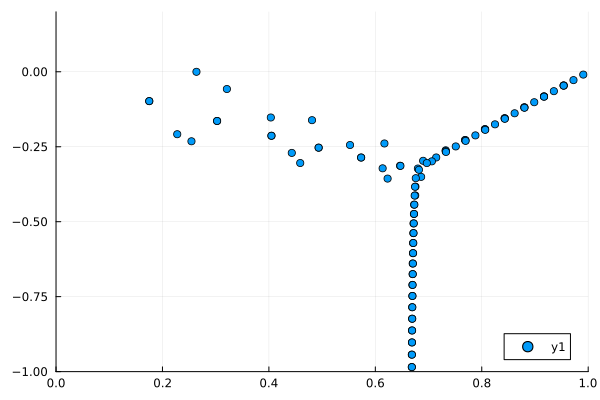

In [108]:
c = omega/alpha
ip = sortperm(c, by=imag, rev=true);
c = c[ip];
phi = phi[:, ip];
scatter(real(c), imag(c), xlims=(0, 1), ylims =(-1, 0.2))

In [109]:
@show c[1:10]


10-element Vector{ComplexF64}:
  0.2638823204330573 - 9.573901889860549e-5im
     47.633379080397 - 0.004794034618184841im
  -46.90311233609062 - 0.004827017104203172im
 -62.053725210092765 - 0.005303030102190245im
   62.75712547608305 - 0.005317833529003939im
   32.77930629657746 - 0.005825923572950074im
  -31.97974341135709 - 0.0060380201747870805im
   -77.3007125134397 - 0.006655179233351957im
   77.99118024772126 - 0.006692192485321478im
  -92.59735780965107 - 0.008634335222821247im

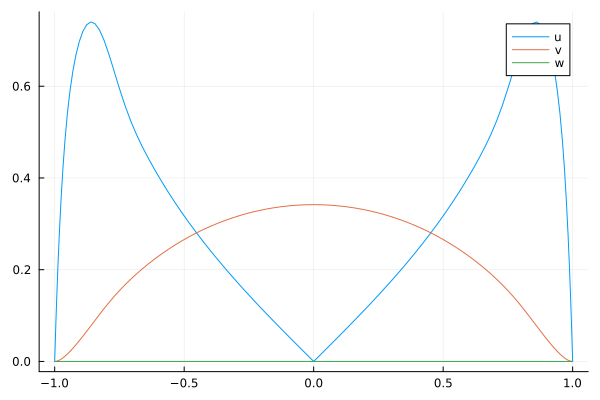

In [115]:
plot(y, abs.(phi[begin:4:end, 1]), label = "|u|")
plot!(y, abs.(phi[begin+1:4:end, 1]), label = "|v|")
plot!(y, abs.(phi[begin+2:4:end, 1]), label = "|w|")